## Experiment Data Analysis
1. Read the real session data from AWS. 
2. Optimizer results demonstration
3. Implemented Prices 
4. Track the peak power for billing cycles 
5. Session statistics -- revenue, cost, net revenue

In [1]:
from deployment_utils import generateSessions, generateExpectedDemand, generateBackupPrices, table_to_stateRecord, unixTime
import pandas as pd 
import time
import pandas as pd
import numpy as np
import datetime
import copy
from collections import defaultdict
import json
import os
import random
from decimal import Decimal



# #### AWS FUNCTIONS ####
from fastapi import FastAPI, Response, status, Body, Request
from fastapi.encoders import jsonable_encoder
from fastapi.middleware.cors import CORSMiddleware
from fastapi.staticfiles import StaticFiles
from fastapi.templating import Jinja2Templates
import boto3, json, hashlib, time, random, pickle
from boto3.dynamodb.conditions import Key, Attr

app = FastAPI()
# Obtain secret key for AWS
txt_path = '/Users/aysetugbaozturk/Documents/eCal/SlrpEV/pev-digital-twin/src/'
f = open(txt_path +"secret.txt")
text = f.readlines()

# Access dynamodb on AWS
dynamodb = boto3.resource(
    "dynamodb",
    aws_access_key_id=text[0][:-1],
    aws_secret_access_key=text[1][:-1],
    region_name="us-east-2")

DAY_SECONDS = 86400
FOUR_HR_SECONDS = 4*3600
NO_SITES = 1
WS_TO_KWH = 1/(1000*3600)
WH_TO_KWH = 1/1000

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

CVXPY version: 1.3.0


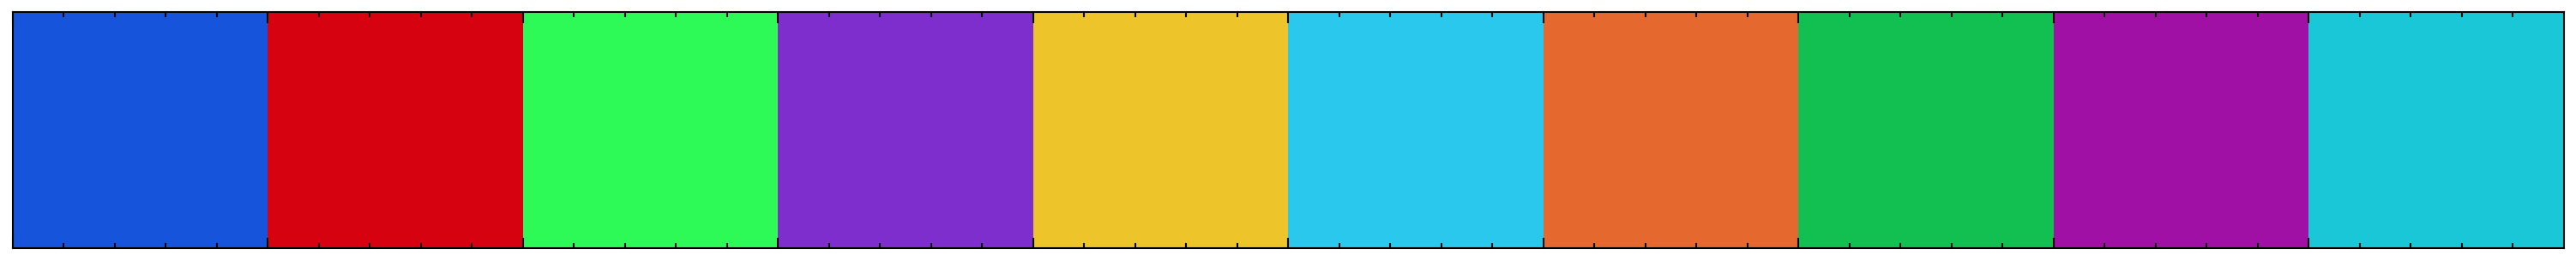

In [2]:
## PLOT SETTINGS
from matplotlib import pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.dates import HourLocator, DateFormatter


plt.style.use(['science','ieee','high-vis'])
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['font.family'] = 'Times New Roman'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] =300
plt.rcParams['font.size'] = 14
matplotlib.rc('xtick', labelsize=13) 
matplotlib.rc('ytick', labelsize=13) 
matplotlib.rc('axes', labelsize=14)

w = 7/1.1
h = 3/1.1

color_palette = [
    '#1655db',  # Slightly darker version of '#0d49fb'
    '#d70210',  # Slightly darker version of '#e6091c'
    '#2df957',  # Lighter shade of '#26eb47'
    '#7d2ecd',  # Desaturated shade of '#8936df'
    '#edc429',  # Slightly desaturated version of '#fec32d'
    '#2ac8ed',  # Desaturated version of '#25d7fd'
    '#e5692f',  # Slightly different shade of '#f07933'
    '#12bf51',  # Slightly darker version of '#14d45e'
    '#a110a4',  # Slightly darker version of '#b812b3'
    # '#edbf0a',  # Slightly darker shade of '#f9cb0b' - colorblind safety
    '#19c7d6'   # Slightly darker version of '#1ad3ea'
]

sns.palplot(color_palette)
plt.show()

In [3]:
def extract_session_powers(session_lst, interval=5):
    session_lst = json.loads(session_lst)
    sessions_powers = []
    sessions_timestamp = []
    for ts_power in session_lst:
        sessions_powers.append(float(ts_power["M"]['power_W']["N"]))
        sessions_timestamp.append(float(ts_power["M"]['timestamp']["N"]))
    session_pow = pd.DataFrame(index =pd.to_datetime(pd.Series(sessions_timestamp),unit='s').dt.floor('{}min'.format(interval)) , 
                                data = {"power_w":sessions_powers})
    session_pow = session_pow.tz_localize("utc").tz_convert("US/Pacific")
    session_pow['power_w'] = session_pow['power_w'].astype(float)
    return session_pow


def extract_session_data(df,row, interval = 5):

    """ Input: DataFrame of historical sessions 
        Everything in 5 min intervals 
    """
    
    start_interval =df.loc[row,"connectTime"].floor('5min') 
    end_interval =df.loc[row,"lastUpdate"].floor('5min') 
    duration_periods = int(df.loc[row,"DurationHrs"] * 60 / interval)
    # Create a dataframe with index from connectTime to disconnectTime time. Round down to nearest 15 minutes? 

    if start_interval < phase3_start:
        session_pow =  extract_session_powers(df.loc[row,"power"])
        assert (session_pow["power_w"].sum() * (interval/60)) / 1000 > 0, "Baseline Power Timestamp Mismatch"
        index = pd.date_range(start= start_interval , end =  end_interval,freq="{}min".format(interval) ,tz="US/Pacific")
    else: 
        start_interval =df.loc[row,"connectTime"].floor('1H') 

        session_pow, est_duration_hours =  extract_optimized_powers(df , powers, row , interval = 15)
        
        session_pow = session_pow.resample('{}min'.format(interval)).ffill()
        duration_periods = int(est_duration_hours * 60 / interval)
        index = pd.date_range(start= start_interval , periods =  duration_periods, freq="{}min".format(interval) ,tz="US/Pacific")
        session_pow_irl =  extract_session_powers(df.loc[row,"power"])
        

         

    

    session_df = pd.DataFrame(index=index, columns = ["userId",  'reg_centsPerHr', 'sch_centsPerHr', 'sch_centsPerOverstayHr', "vehicle_maxChgRate_W","" ,"connectionStatus", "chargingStatus","overstayStatus","power_w"])


    
    assert session_pow.index[0] >= session_df.index[0], "Charging strats before connection {} >= {}".format(session_pow.index,session_df.index )

    # power_w column must be null when not charging 
    session_df["power_w"] =session_pow
    session_df["userId"] = df.loc[row,"userId"]
    session_df["dcosId"] = df.loc[row,"dcosId"]
    session_df["choice"] = df.loc[row,"choice"] 
    session_df["reg_centsPerHr"] = df.loc[row,"reg_centsPerHr"] 
    session_df["sch_centsPerHr"] = df.loc[row,"sch_centsPerHr"] 
    session_df["sch_centsPerOverstayHr"] = df.loc[row,"sch_centsPerOverstayHr"] 
    session_df["vehicle_maxChgRate_W"] = df.loc[row,"vehicle_maxChgRate_W"] 
    session_df["connectionStatus"] = 1
    session_df["chargingStatus"] = (~session_df["power_w"].isnull()).astype(int)
    session_df["overstayStatus"] = 0
    session_df["TOU (cents/kwh)"] = sessions_TOU(start_interval.date())["TOU (cents/kwh)"]
    session_df["DurationHrs"] = df.loc[row,"DurationHrs"]
    if start_interval < phase3_start:
        session_df['connectedDuration_Hrs'] = (df.loc[row,'lastUpdate'] - df.loc[row,'connectTime']).seconds / 3600 
    else: 
        session_df['connectedDuration_Hrs'] = est_duration_hours
    
    try:
        session_df['Energy_IRL'] =(float(session_pow_irl.sum()) * (interval/60)) / 1000
    except: 
        session_df['Energy_IRL'] =(float(session_pow.sum()) * (interval/60)) / 1000
    return session_df

In [72]:
####### CHOICE: WHICH TIMEFRAME TO USE FOR THE EXPECTED DEMAND TABLE ##### 
session_df = generateSessions(2023, 11, 19, 23,
                                    2024, 3, 21, 0,
                                    write_output = False,
                                    all_data = False,
                                    path = "/Users/aysetugbaozturk/Documents/eCal/SlrpEV/SlrpEV_algorithms/",
                                    f_name = "",
                                    read_from_file=False)

Length of Scanned Items is 941 items
Length of Scanned Items is 1864 items
Length of Scanned Items is 2824 items
Length of Scanned Items is 3761 items
Length of Scanned Items is 4736 items
Length of Scanned Items is 5677 items
Elapsed time: 0 minutes, 31 seconds
5677
From 2023-11-19 23:00:00 till 2024-03-21 00:00:00 (incl.)


In [73]:
######## General Statistics of the Experiment ####### 
print("Total sessions:", len(session_df))
print("REG sessions:", session_df.groupby(['choice']).count().loc['REGULAR','dcosId'])
print("SCH sessions:", session_df.groupby(['choice']).count().loc['SCHEDULED','dcosId'])

Total sessions: 756
REG sessions: 553
SCH sessions: 203


In [88]:
8 * 6.6

52.8

In [74]:
start_date = pd.Timestamp("2023-11-20")
def assign_period(date):
    elapsed_days = (date - start_date).days
    return elapsed_days // 30 + 1
def cost_column(choice):
    if choice == 'REGULAR':
        return "reg_centsPerHr"
    else:
        return "sch_centsPerHr"

In [75]:

# off-peak 0.175  cents / kwh 
TOU_tariff = np.ones((96,)) * 17.5
## 4 pm - 9 pm peak 0.367 cents / kwh 
TOU_tariff[64:84] = 36.7
## 9 am - 2 pm super off-peak 0.49 $ / kWh  to cents / kwh

TOU_tariff[36:56] = 14.9

In [76]:
def cost_calculate(row):
    if row['arrHour'] <= 9:
        return row["cumEnergy_KWh"] * 17.5
    
    if row['arrHour'] <= 14:
        return row["cumEnergy_KWh"] * 14.9
    
    if row['arrHour'] <= 21:
        return row["cumEnergy_KWh"] * 36.7
    
    else:
        return row["cumEnergy_KWh"] * 17.5


def assign_date(p):
    if p == 1:
        return "11/20/23-12/20/23"
    if p == 2:
        return "12/21/23-1/20/24"
    if p == 3:
        return "1/21/24-2/20/24"
    if p == 4:
        return "2/21-3/21/24"
    
def max_dc(row):
    if row['highPower'] == 1.0:
        return row['Net Revenue'] / 6.6
    else:
        return row['Net Revenue'] / 3.6
    
def est_en(row):
    if row["cumEnergy_KWh"] == 0:
        
        if row['highPower'] == 1.0:
            return 23
        else:
            return 8
    else:
        return row["cumEnergy_KWh"]

In [85]:
session_df = session_df.sort_values(by='Billing Period',inplace=True)

AttributeError: 'NoneType' object has no attribute 'sort_values'

In [84]:
session_df["cumEnergy_KWh"] = session_df.apply(est_en,axis=1)
session_df['Billing Period'] = session_df['connectTime'].apply(assign_period)

session_df['tariffColumn'] = session_df['choice'].apply(cost_column)
session_df = session_df.reset_index(drop=True)
tariff  = [float(session_df.loc[i,col]) * float(session_df.loc[i,"DurationHrs"])  for (i,col) in enumerate(session_df['tariffColumn'])]
session_df.loc[:,'Revenue'] = tariff


session_df['Cost'] = session_df.apply(cost_calculate, axis=1)
# session_df["Billing Period"] = session_df["Billing Period"].apply(assign_date)
session_df["Billing Period"] = session_df["Billing Period"].apply(assign_date)
session_df["Net Revenue"] = session_df['Revenue'] - session_df['Cost']

TypeError: 'NoneType' object is not subscriptable

In [78]:
monthly_sums = session_df.groupby(['Billing Period']).sum()[["DurationHrs","cumEnergy_KWh","Revenue","Cost"]]
monthly_sums["Net Revenue"] = monthly_sums['Revenue'] - monthly_sums['Cost']
monthly_sums['Max Peak (kW)'] = 7 * 6.6 + 3.3
monthly_sums['DC Cost (cents)'] = monthly_sums['Net Revenue'] / monthly_sums['Max Peak (kW)']

Text(0.5, 0, 'DC_max = (Net Revenue / Peak Power)')

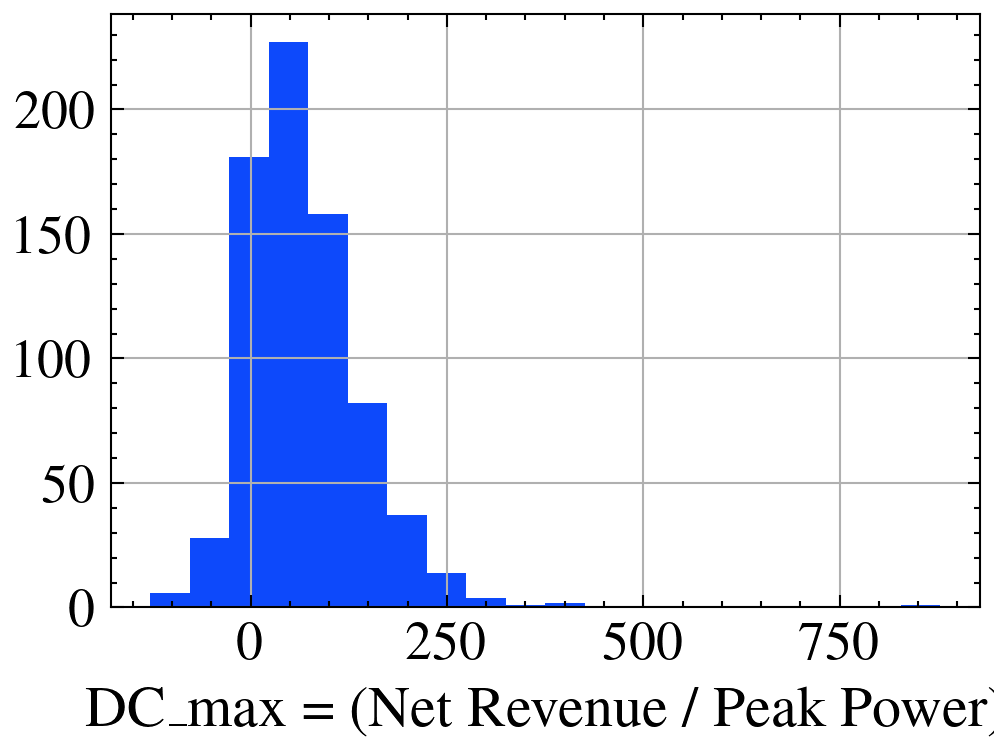

In [68]:
session_df['Session DC Max'] = session_df.apply(max_dc,axis=1)
ax = session_df['Session DC Max'].hist(bins = 20)
ax.set_xlabel('DC_max = (Net Revenue / Peak Power)')

In [82]:
monthly_sums.loc["11/20-12/20"] ## given the revenue and cost -- 
# think of this as assuming -- DC cost is 1800 then what is the peak value that we should not exceed. 
# To make zero

DurationHrs           825.035800
cumEnergy_KWh        3774.139000
Revenue            148749.245790
Cost                67383.990300
Net Revenue         81365.255490
Max Peak (kW)          49.500000
DC Cost (cents)      1643.742535
Name: 11/20-12/20, dtype: float64

In [83]:
monthly_sums

,DurationHrs,cumEnergy_KWh,Revenue,Cost,Net Revenue,Max Peak (kW),DC Cost (cents)
Billing Period,,,,,,,
1/21-2/20,978.17190,4730.557,158488.63992,88446.0051,70042.63482,49.5,1415.002724
11/20-12/20,825.03580,3774.139,148749.24579,67383.9903,81365.25549,49.5,1643.742535
12/21-1/20,512.84175,2626.810,87586.34692,47615.6072,39970.73972,49.5,807.489691
2/21-3/21,964.74921,4481.510,182517.45499,83946.6908,98570.76419,49.5,1991.328569


In [17]:
# table = dynamodb.Table('stateRecords_History')

# # Scan the table
# response = table.scan()
# response['Items']

def scan_stateRecord_History():
    # Dictionary to store the data
    stateRecords = []

    table = dynamodb.Table('stateRecords_History')

    # Scan the table
    response = table.scan()

    # Handle Decimal types coming from DynamoDB
    def decimal_default(obj):
        if isinstance(obj, Decimal):
            return float(obj)
        raise TypeError
    print(len(response['Items']))
    # Process scanned items
    for item in response['Items']:
        
        try: 
            timestamp = decimal_default(item['timestamp'])
        except KeyError:
            timestamp = decimal_default(item['timeStamp'])

        # Populate data
        stateRecord= {"timestamp":int(timestamp),
                      "sort_key":int(decimal_default(item['sort_key'])),
                    'monthlyPeak': decimal_default(item['monthlyPeak']),
                    'sessions': [
                {
                    'dcosId': int(session['dcosId']),
                    'choice': session['choice'],
                    'powerRate': session['powerRate'],
                    'energyNeeded': decimal_default(session['energyNeeded']),
                    'optPower': [[decimal_default(x) for x in pair] for pair in session['optPower']],
                    'deadline': int(session['deadline'])
                } for session in item['sessions']]
        }
        stateRecords.append(stateRecord)
    return stateRecords

# Handle Decimal types coming from DynamoDB
def decimal_default(obj):
    if isinstance(obj, Decimal):
        return float(obj)
    raise TypeError

In [22]:
stateRecords = scan_stateRecord_History()
# Convert to DataFrame
df = pd.DataFrame(stateRecords, columns=['timestamp', 'sort_key','monthlyPeak', 'sessions'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

df.rename(columns={'timestamp':'opt_timestamp'},inplace=True)
df['opt_timestamp'] = pd.to_datetime(df['opt_timestamp'],unit='s')
df_exp = df[df['opt_timestamp'] >= pd.Timestamp(year=2023, month=11, day= 18, hour=23)].reset_index(drop=True)
df_exp['opt_timestamp'] = pd.to_datetime(df_exp['opt_timestamp'],unit='s')
df_exp.sort_values(by= 'opt_timestamp',inplace=True)
# df_exp = df_exp.drop_duplicates(subset='opt_timestamp',keep='last')
# df_exp.reset_index(drop=True,inplace=True)
df_exp = df_exp.sort_values(by=['opt_timestamp','sort_key']).drop_duplicates(subset='opt_timestamp',keep='last')
df_exp.reset_index(drop=True,inplace=True)

2249


In [23]:
df_exp.tail(50)

,opt_timestamp,sort_key,monthlyPeak,sessions
1201,2024-03-28 07:30:20,0,33.0,"[{'dcosId': 7545, 'choice': 'REG', 'powerRate'..."
1202,2024-03-28 07:42:37,0,33.0,"[{'dcosId': 7545, 'choice': 'REG', 'powerRate'..."
1203,2024-03-28 08:15:00,2,33.0,"[{'dcosId': 7545, 'choice': 'REG', 'powerRate'..."
1204,2024-03-28 08:58:55,0,33.0,"[{'dcosId': 7546, 'choice': 'SCH', 'powerRate'..."
1205,2024-03-28 10:15:50,0,33.0,"[{'dcosId': 7546, 'choice': 'SCH', 'powerRate'..."
1206,2024-03-28 12:15:00,2,33.0,"[{'dcosId': 7546, 'choice': 'SCH', 'powerRate'..."
1207,2024-03-28 16:15:00,0,33.0,"[{'dcosId': 7548, 'choice': 'REG', 'powerRate'..."
1208,2024-03-28 20:15:00,0,33.0,[]
1209,2024-03-29 00:15:00,0,33.0,[]
1210,2024-03-29 04:15:00,0,33.0,[]


In [27]:
# Create a dataframe for all completed sessions indexed by the timestamp values since the beginning of the experiment
unix_time_index = np.arange(start=unixTime(pd.Timestamp(year=2023,month=11,day=18,hour=23)),
                            stop= unixTime(pd.Timestamp(year=2024,month=4,day=2,hour=14)), step = 15 * 60)

df_sessions = pd.DataFrame(index = unix_time_index)


for row in range(len(df_exp)):
    sessions = df_exp.loc[row,"sessions"]
    optTime = df_exp.loc[row,"opt_timestamp"]
    sk = df_exp.loc[row,"sort_key"]
    if len(sessions) > 0 :
        for session in sessions:
            dcosId = session['dcosId']
            
            power = session['optPower']
            temp = pd.DataFrame(session['optPower'],dtype='int').set_index(0)

            col_name = str(dcosId)+"_"+str(sk)+"_"+str(optTime)
            col_name = str(dcosId)
            df_sessions[col_name] = temp

df_sessions.reset_index(drop=False,inplace=True, names='timestamp')
df_sessions['timestamp'] = pd.to_datetime(df_sessions['timestamp'].values,unit='s')
df_sessions.set_index('timestamp',inplace=True)

## dont fillna, we need that to count charger occupancy
df_sessions=df_sessions[df_sessions.index>pd.Timestamp(year=2023,month=11,day=1,hour=0)]
num_charging_vehicles = (~df_sessions.isnull()).sum(axis=1)

## dont fillna, we need that to count charger occupancy
peak_df = (df_sessions.fillna(0).sum(axis=1) / 1000)
# Set x-ticks at 12-hour intervals
tick_spacing = 48 *8 # There are 4 data points per hour, so 48 points for 12 hours
tick_labels = peak_df.index[::tick_spacing].strftime('%m-%d')  # Labels for every 12 hours

In [52]:
peak_df = peak_df.replace({66:8*(6.6)})
peak_df = peak_df.replace({(9 * 6.6 ):8*(6.6)})

num_charging_vehicles = num_charging_vehicles.replace({10:8})
num_charging_vehicles = num_charging_vehicles.replace({9:8})

In [53]:
num_charging_vehicles[-40:]

timestamp
2024-04-02 04:00:00    0
2024-04-02 04:15:00    1
2024-04-02 04:30:00    1
2024-04-02 04:45:00    1
2024-04-02 05:00:00    1
2024-04-02 05:15:00    1
2024-04-02 05:30:00    1
2024-04-02 05:45:00    1
2024-04-02 06:00:00    1
2024-04-02 06:15:00    1
2024-04-02 06:30:00    1
2024-04-02 06:45:00    1
2024-04-02 07:00:00    1
2024-04-02 07:15:00    1
2024-04-02 07:30:00    1
2024-04-02 07:45:00    2
2024-04-02 08:00:00    2
2024-04-02 08:15:00    3
2024-04-02 08:30:00    4
2024-04-02 08:45:00    4
2024-04-02 09:00:00    5
2024-04-02 09:15:00    5
2024-04-02 09:30:00    5
2024-04-02 09:45:00    5
2024-04-02 10:00:00    5
2024-04-02 10:15:00    5
2024-04-02 10:30:00    5
2024-04-02 10:45:00    4
2024-04-02 11:00:00    4
2024-04-02 11:15:00    4
2024-04-02 11:30:00    4
2024-04-02 11:45:00    4
2024-04-02 12:00:00    4
2024-04-02 12:15:00    5
2024-04-02 12:30:00    4
2024-04-02 12:45:00    5
2024-04-02 13:00:00    5
2024-04-02 13:15:00    5
2024-04-02 13:30:00    4
2024-04-02 13:4

In [54]:
num_charging_vehicles["2024-03-24 10:30:00"]

8

In [55]:
8*6.6

52.8

In [89]:
peak_df.sort_values()[-10:]

timestamp
2024-03-24 11:00:00    52.8
2024-03-24 12:30:00    52.8
2024-03-24 10:45:00    52.8
2024-03-24 10:15:00    52.8
2024-03-24 10:30:00    52.8
2024-03-24 13:00:00    52.8
2024-03-24 13:45:00    52.8
2024-03-24 13:30:00    52.8
2024-03-24 12:15:00    52.8
2024-03-24 12:45:00    52.8
dtype: float64

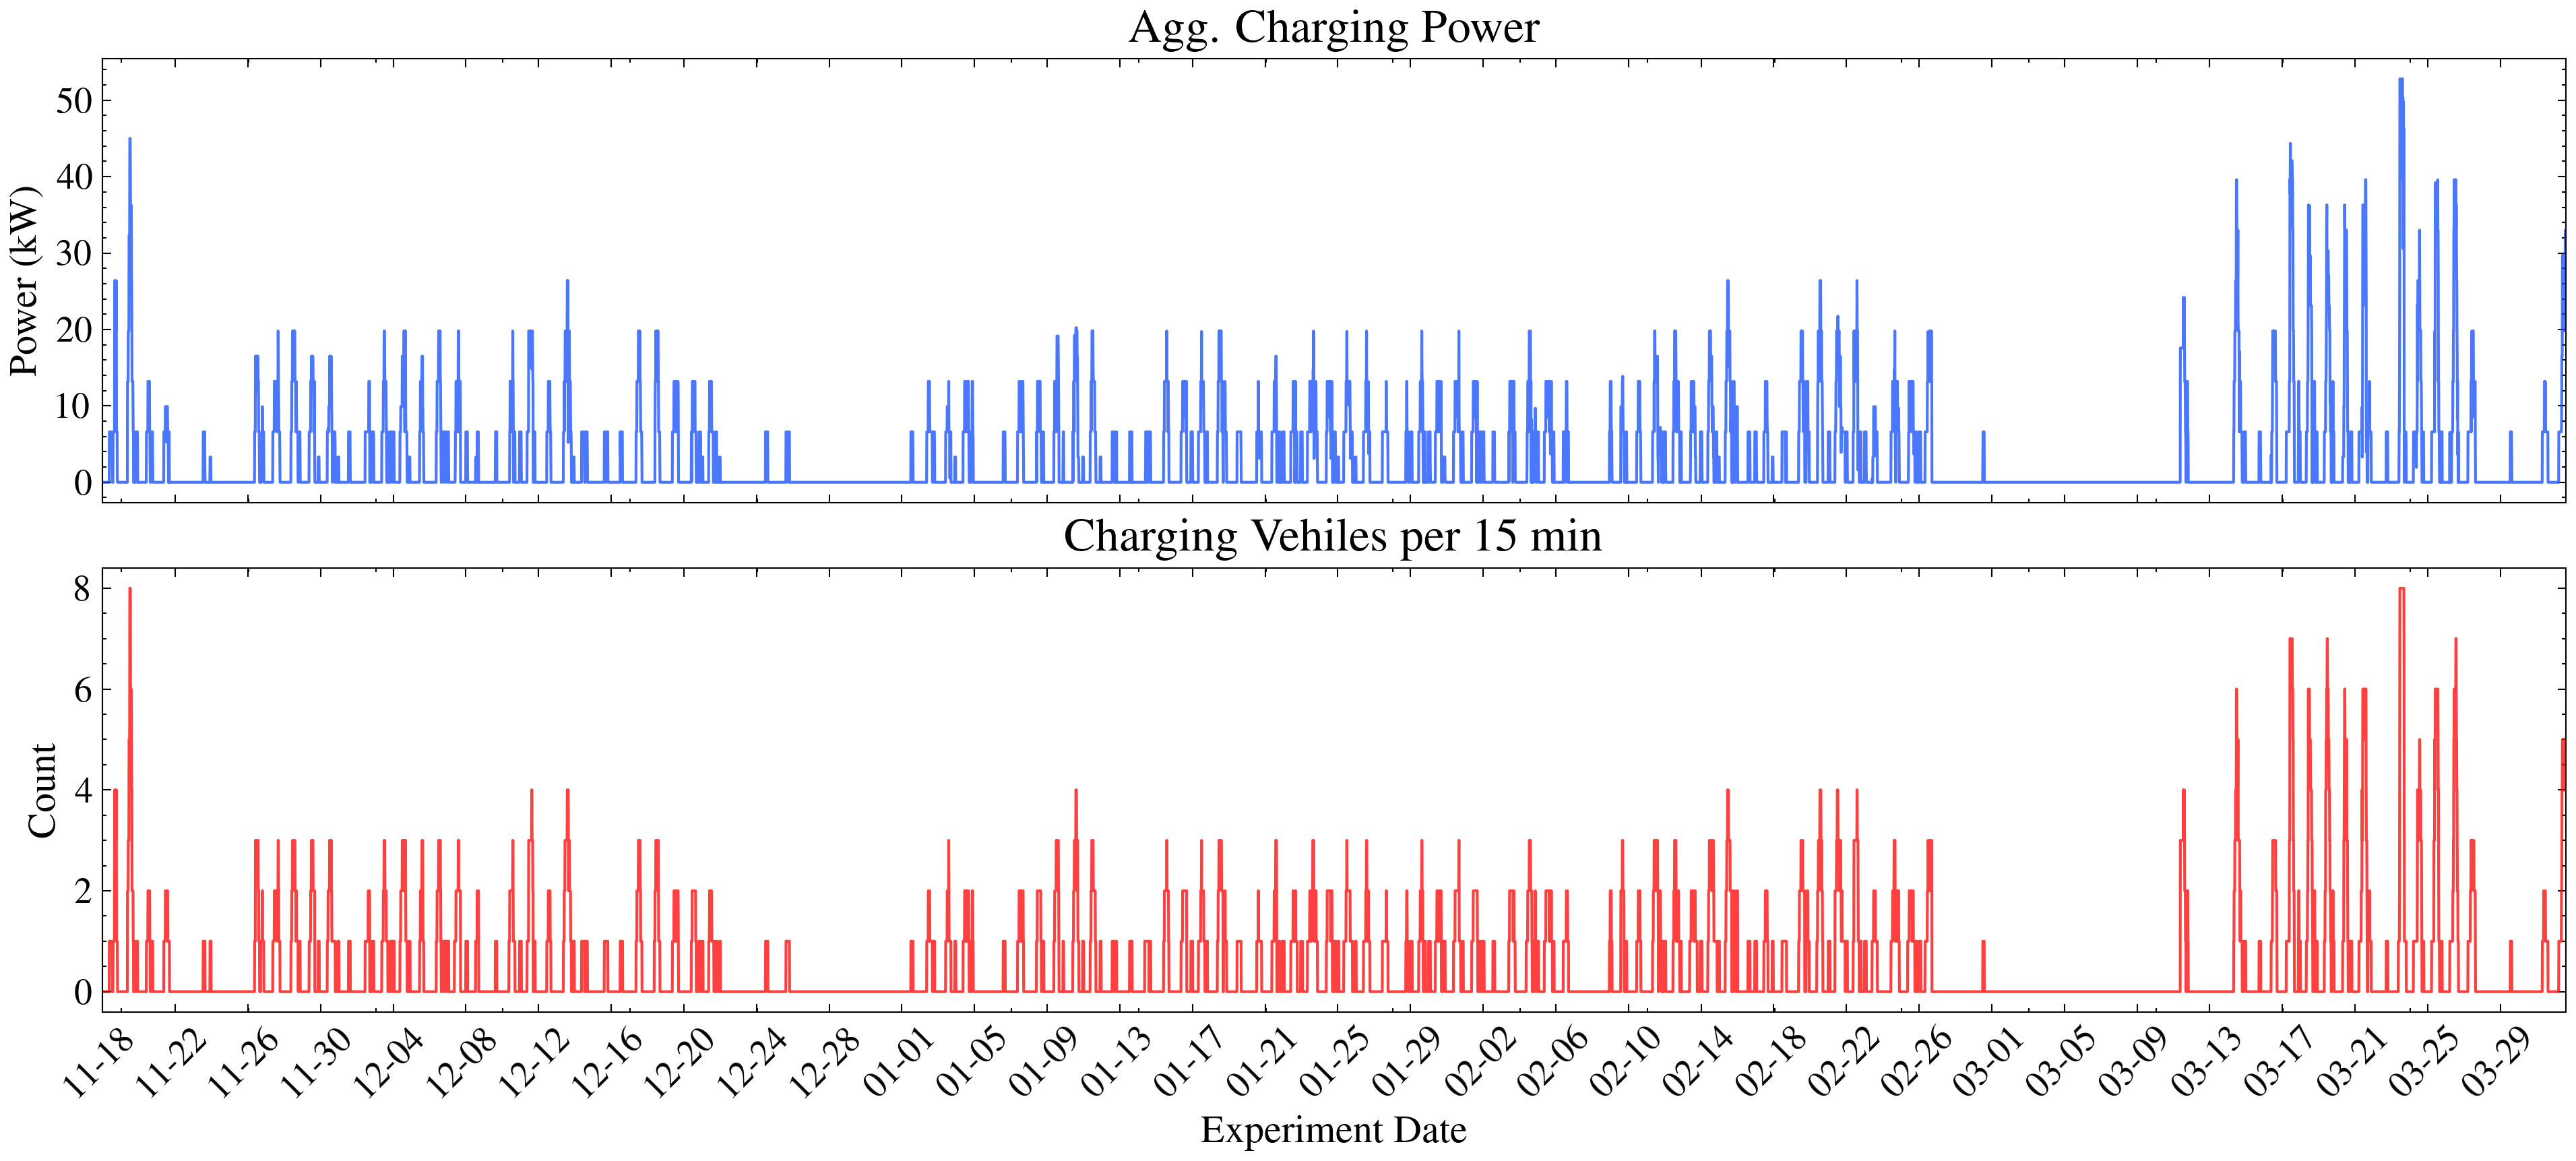

In [56]:
fig, axs= plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(2*w,h*2.1))
ax = axs[0]
peak_df.plot(alpha=0.75,ax=ax)
# ax.axvline('2023-11-21 00:00:00',color='purple',linestyle='--',lw=3)
ax.set_ylabel('Power (kW)')
ax.set_title('Agg. Charging Power')

ax = axs[1]
num_charging_vehicles.plot(color='red', alpha=0.75,ax=ax)

ax.set_xticklabels([])
ax.set_xticks(peak_df .index[::tick_spacing], tick_labels, rotation=45)
ax.set_xlabel('Experiment Date')
ax.set_ylabel('Count')
ax.set_title('Charging Vehiles per 15 min')

# ax.axvline('2023-11-21 00:00:00',color='purple',linestyle='--',lw=3)

plt.tight_layout()
plt.show()



,choice,vehicle_maxChgRate_W,siteId,peakPower_W,estCost,sch_centsPerHr,connectTime,DurationHrs,vehicle_model,dcosId,...,Deadline,energyReq_Wh,arrHour,cumEnergy_KWh,historical_peakPower_w,endTime,highPower,userPower_kW,month,date
3351,REGULAR,100000,25,6726,4.98374,200,2024-02-27 09:50:11,2.98916,Kona,7232,...,NaT,NaN,9,19.063,6811,2024-02-27 12:50:05,1.0,6.6,2,2024-02-27
3103,REGULAR,7000,25,6802,10.55958,200,2024-02-27 09:57:01,6.70638,Model Y,7233,...,NaT,NaN,9,30.572,6802,2024-02-27 16:40:05,1.0,6.6,2,2024-02-27
5185,REGULAR,11000,25,3370,3.02401,99,2024-02-27 10:28:21,2.27388,Volt,7234,...,NaT,NaN,10,7.218,3449,2024-02-27 12:45:06,0.0,3.3,2,2024-02-27
3669,SCHEDULED,7700,25,6714,9.91694,175,2024-02-27 13:06:15,5.04916,Model 3,7238,...,2024-02-27 18:30:00,34544,13,31.944,6830,2024-02-27 18:10:05,1.0,6.6,2,2024-02-27
5334,REGULAR,7400,25,6197,1.82119,180,2024-02-27 14:22:33,0.62027,Wrangler 4ex,7240,...,NaT,NaN,14,3.514,8371,2024-02-27 15:00:07,1.0,6.6,2,2024-02-27


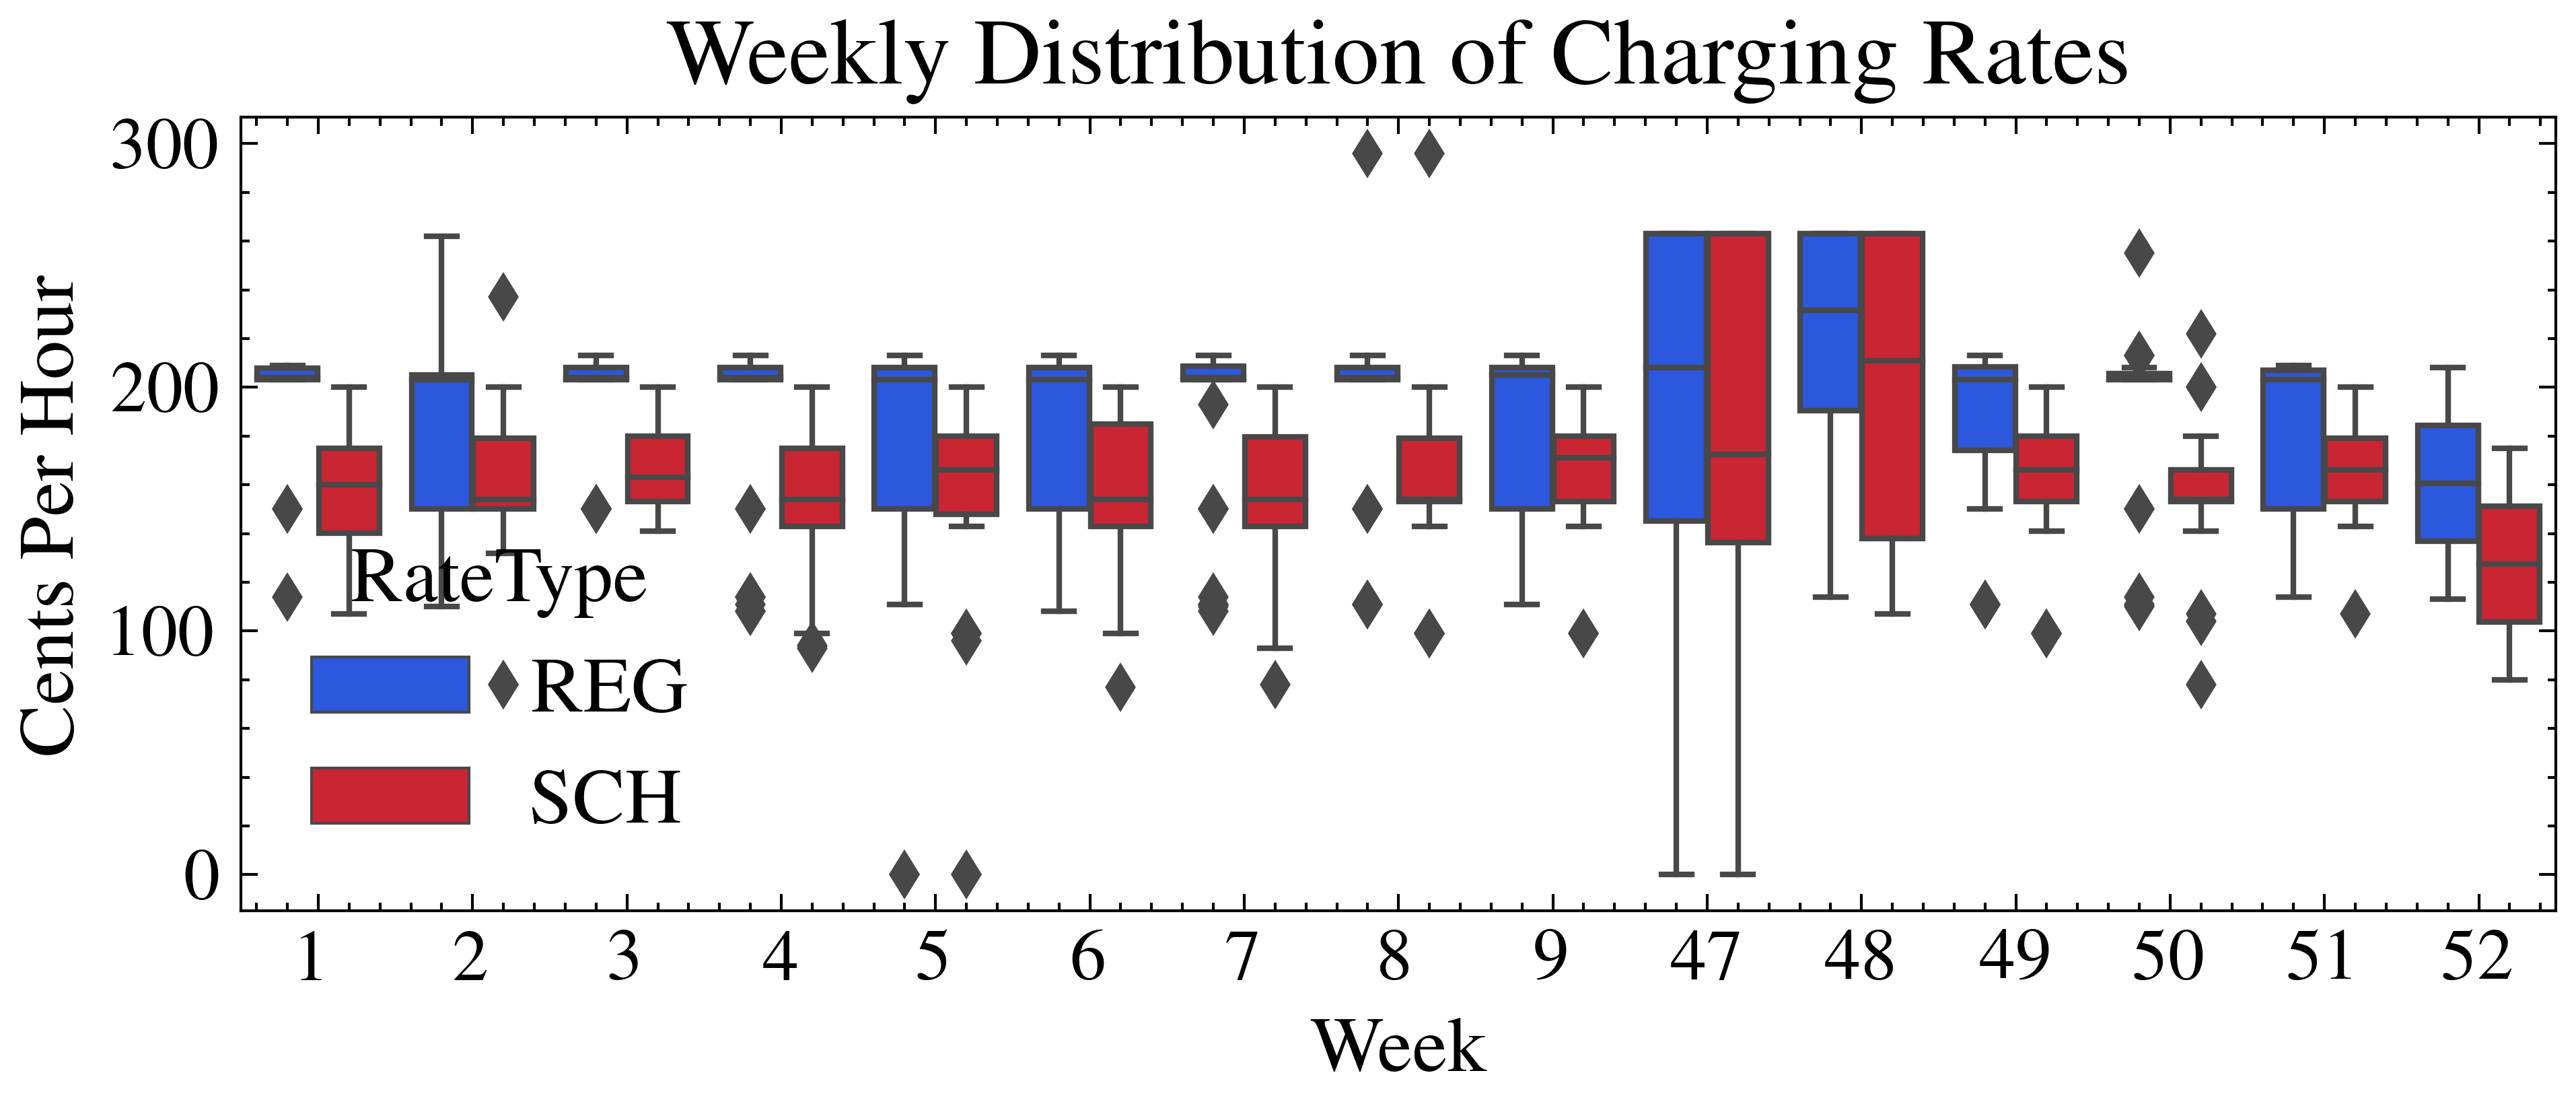

In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample DataFrame

df_sessions = session_df.copy()

# Convert connectTime to datetime
df_sessions['connectTime'] = pd.to_datetime(df_sessions['connectTime'])

# Extract week number
df_sessions['week'] = df_sessions['connectTime'].dt.isocalendar().week

# Reshape the DataFrame for seaborn's violinplot
df_melted = pd.melt(df_sessions, id_vars=['userId', 'connectTime', 'choice', 'week'], value_vars=['reg_centsPerHr', 'sch_centsPerHr'], var_name='RateType', value_name='centsPerHr')
df_melted['centsPerHr'] = df_melted['centsPerHr'].astype(float)
df_melted['RateType'] = df_melted['RateType'].replace({"reg_centsPerHr":"REG", 
                               "sch_centsPerHr":"SCH"})
# Remove NaN values for the plot
df_melted.dropna(inplace=True)

# Plot
plt.figure(figsize=(w, h))
sns.boxplot(data=df_melted, 
            x='week', 
            y='centsPerHr', 
            hue='RateType')

plt.title('Weekly Distribution of Charging Rates')
plt.xlabel('Week')
plt.ylabel('Cents Per Hour')
plt.show()


In [136]:
df_sessions = df_sessions[df_sessions['diff'] != -50]

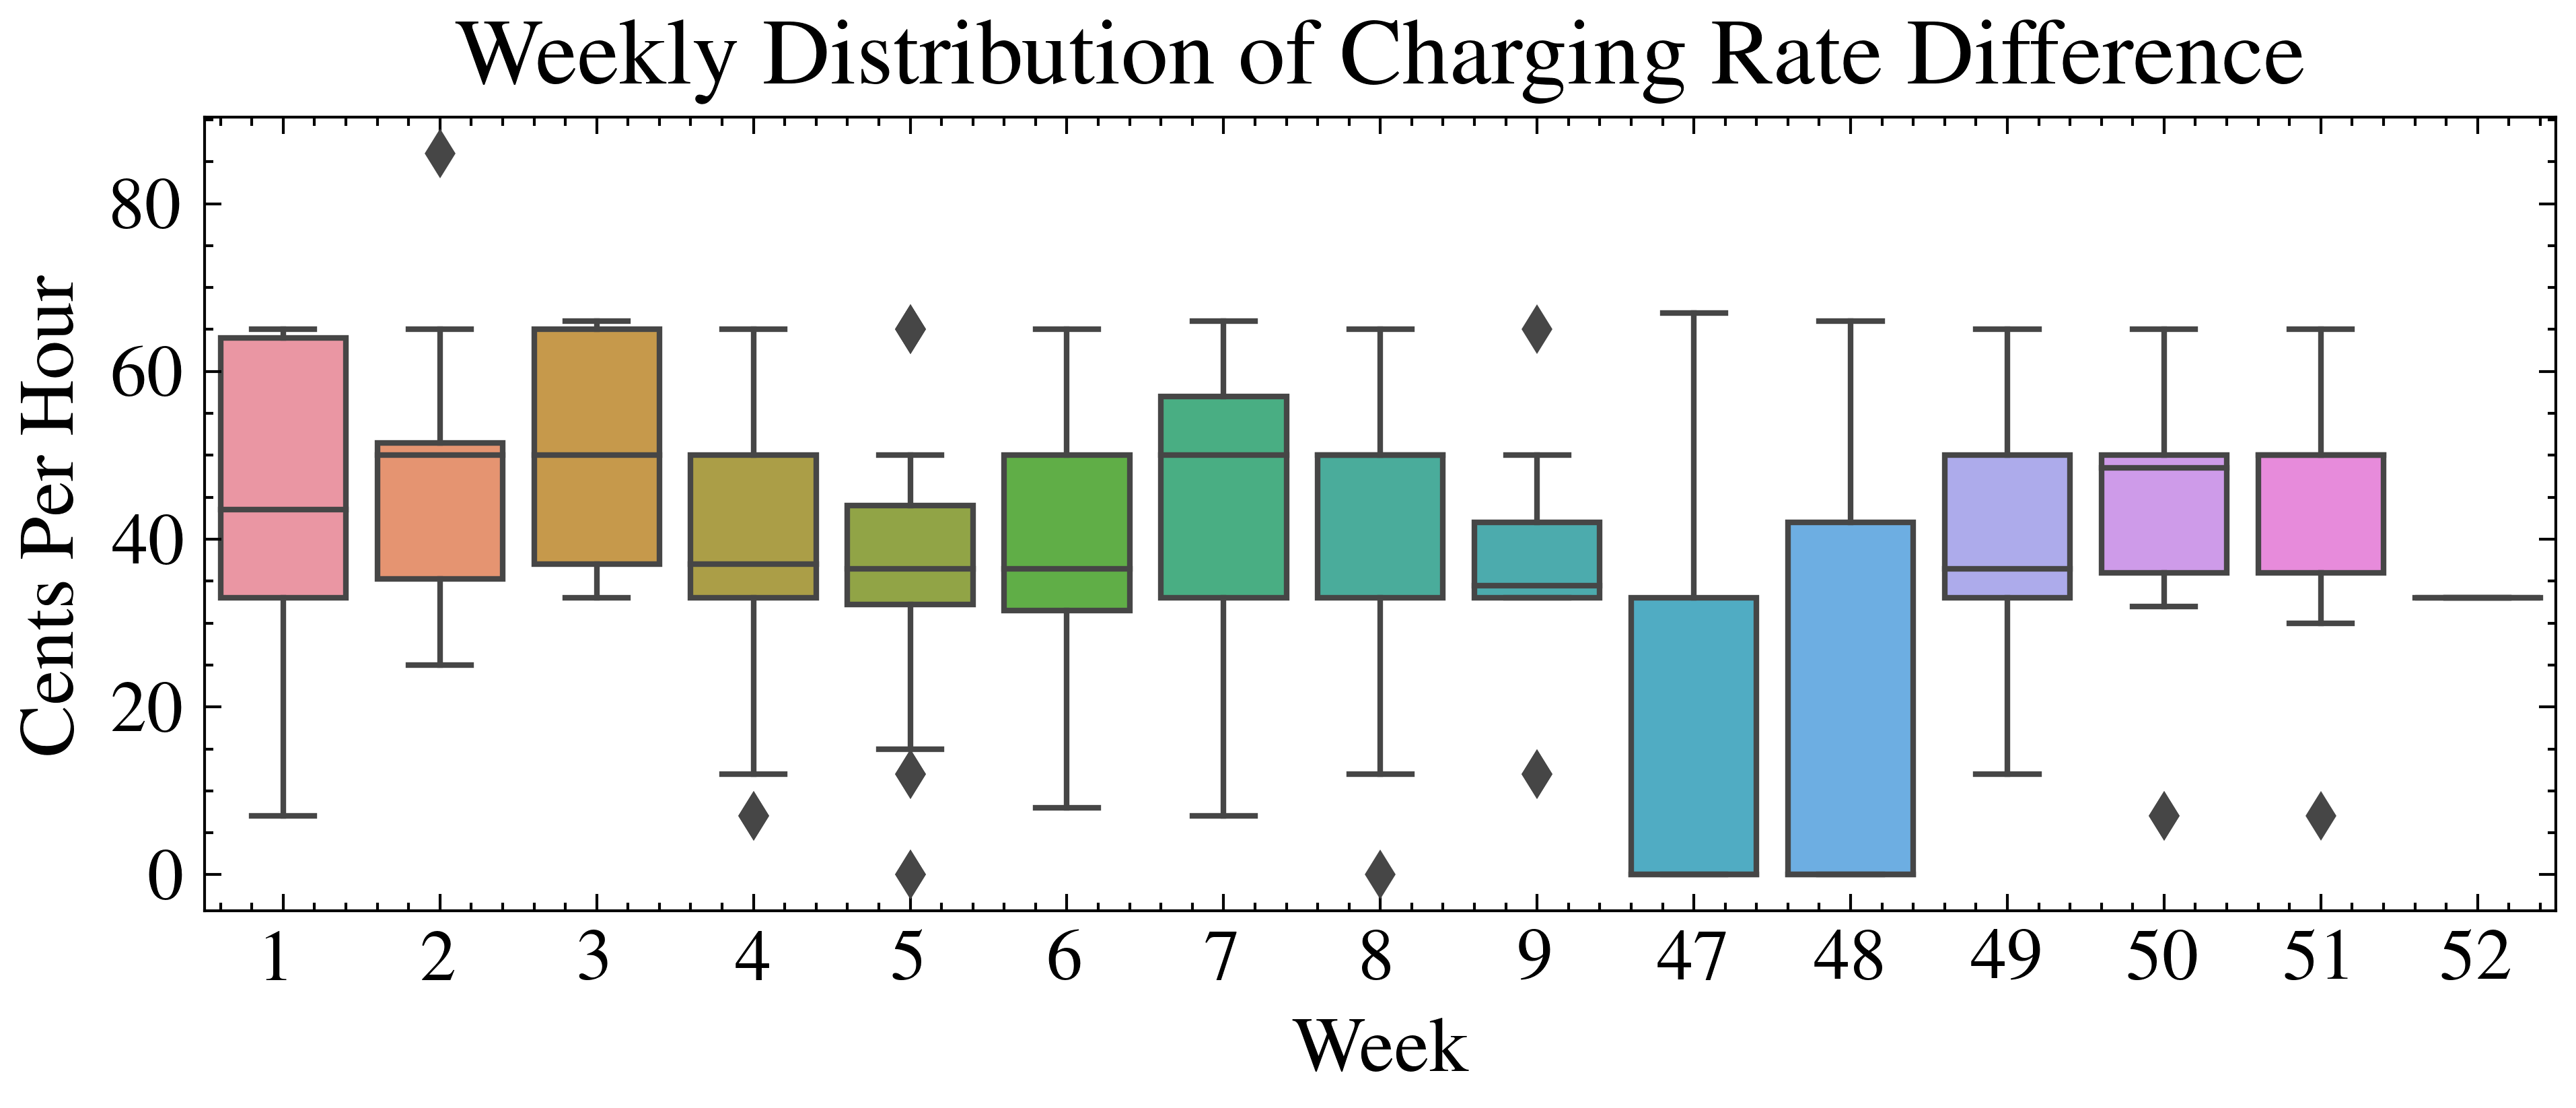

In [142]:
df_sessions['diff'] = (df_sessions['reg_centsPerHr']-df_sessions['sch_centsPerHr']).astype(float)
plt.figure(figsize=(w, h))
sns.boxplot(data=df_sessions, x='week', y='diff')
plt.title('Weekly Distribution of Charging Rate Difference')
plt.xlabel('Week')
plt.ylabel('Cents Per Hour')
plt.show()

In [103]:
# print(len(df.loc[392,'sessions']),df.loc[392,'sessions'])

# print(len(df.loc[402,'sessions']), df.loc[402,'sessions'])  # 6290, 6291,6292, 6293, 6294, 6295  (11:50)

# print(len(df.loc[403,'sessions']), df.loc[403,'sessions']) # 6291,6292, 6293, 6294, 6295,6295, 6296
# df.loc[403,'sessions'][5],df.loc[403,'sessions'][6],df.loc[403,'sessions'][7]
session_df[['userId','connectTime','choice','reg_centsPerHr','sch_centsPerHr']].tail(20)

,userId,connectTime,choice,reg_centsPerHr,sch_centsPerHr
3995,1380,2024-02-24 10:34:15,REGULAR,209,179
3989,1469,2024-02-24 13:31:24,REGULAR,208,175
3347,1027,2024-02-24 14:02:23,SCHEDULED,213,180
3521,1258,2024-02-25 11:04:22,REGULAR,204,154
3927,1411,2024-02-25 13:19:00,REGULAR,208,175
1675,909,2024-02-25 17:36:22,REGULAR,208,143
3996,1380,2024-02-25 19:10:44,REGULAR,208,143
3971,1442,2024-02-26 08:03:53,REGULAR,203,153
3164,1178,2024-02-26 09:05:42,REGULAR,205,163
2480,1139,2024-02-26 09:11:19,REGULAR,150,200


In [68]:
# Process the data using iterrows
# def generate_stateRecord_df():

df = pd.DataFrame(stateRecords, 
                  columns=['timestamp', 'sort_key','monthlyPeak', 'sessions'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

df.rename(columns={'timestamp':'opt_timestamp'},inplace=True)
df['opt_timestamp'] = pd.to_datetime(df['opt_timestamp'],unit='s')

processed_data = []

for _, row in df.iterrows():
    sessions = row['sessions']
    if len(sessions) >0:
        ### Changing minds --> now we want to 
        threshold_ts = unixTime(row['opt_timestamp'] )
        # Counting sessions and identifying duplicates
        session_ids = [session['dcosId'] for session in sessions]
        num_sessions = len(session_ids)
        duplicates = {dcosId for dcosId in session_ids if session_ids.count(dcosId) > 1}
        if len(duplicates)>=1:
            duplicates = list(duplicates)
        else: 
            duplicates = None
        # Finding the overall time range for the power profiles
        all_timestamps = sorted({timestamp for session in sessions for timestamp, _ in session['optPower']})

        # Creating the power profile array
        power_profile = np.zeros((num_sessions, len(all_timestamps)))

        for i, session in enumerate(sessions):
            session_times = {timestamp for timestamp, _ in session['optPower']}
            for j, timestamp in enumerate(all_timestamps):
                if timestamp in session_times:
                    power = next(power for time, power in session['optPower'] if time == timestamp)
                    power_profile[i, j] = power

        observed_power_profile = power_profile[:, [t <= threshold_ts for t in all_timestamps]]
        planned_power_profile = power_profile[:, [t >= threshold_ts for t in all_timestamps]]


        # Appending to processed data
        processed_data.append({
            'num_sessions': num_sessions,
            'duplicated_session': duplicates,
            'power_profile': power_profile,
            'peak_value':  np.max(np.sum(power_profile, axis=0)),
            'observed_peak_value': np.max(np.sum(observed_power_profile, axis=0)),
            'observed_power_profile': observed_power_profile,
            'planned_power_profile': planned_power_profile,
            'session_ids':session_ids,
            'all_timestamps':all_timestamps
        })

    else:
            processed_data.append({
            'num_sessions': 0,
            'duplicated_session': None,
            'power_profile': [],
            'peak_value':  0,
            'observed_peak_value': 0,
            'observed_power_profile': [],
            'planned_power_profile': [],
            'session_ids':[],
            'all_timestamps':[]
            })
# processed_data now contains the results for each row of the DataFrame
# Add new columns to the DataFrame
df['num_sessions'] = 0
df['duplicated_session'] = None
df['power_profile'] = None
df['peak_value'] = 0
df['observed_peak_value'] = 0
df['observed_power_profile'] = None
df['planned_power_profile'] = None
df['all_timestamps'] = None
df['session_ids'] = None

for index, processed_row in enumerate(processed_data):
    df.at[index, 'num_sessions'] = processed_row['num_sessions']
    df.at[index, 'duplicated_session'] = processed_row['duplicated_session']
    df.at[index, 'power_profile'] = processed_row['power_profile']
    df.at[index, 'peak_value'] = processed_row['peak_value']
    df.at[index, 'observed_peak_value'] = processed_row['observed_peak_value']
    df.at[index, 'observed_power_profile'] = processed_row['observed_power_profile']
    df.at[index, 'planned_power_profile'] = processed_row['planned_power_profile']
    df.at[index, 'all_timestamps'] = processed_row['all_timestamps']
    df.at[index, 'session_ids'] = processed_row['session_ids']
df = df[df['opt_timestamp'] > pd.Timestamp(year=2023,month=10,day=26,hour=8)]
df = df.sort_values(by=['opt_timestamp','sort_key']).drop_duplicates(subset='opt_timestamp',keep='last')
df = df.drop_duplicates('session_ids',keep='first')
# return df

In [70]:
session_df['']

,choice,vehicle_maxChgRate_W,siteId,peakPower_W,estCost,sch_centsPerHr,connectTime,DurationHrs,vehicle_model,dcosId,...,sch_centsPerKwh,sch_centsPerOverstayHr,Deadline,energyReq_Wh,arrHour,cumEnergy_KWh,historical_peakPower_w,endTime,highPower,userPower_kW
4860,REGULAR,6600,25,0,11.14878,166,2023-10-16 07:48:56,5.43305,Leaf (30 kW-hr upgraded),6099,...,0,300,NaT,NaN,7,24.199,6522,2023-10-16 13:15:05,1.0,6.6
5041,REGULAR,11000,25,6813,9.54284,168,2023-10-16 08:04:26,4.59027,Model Y,6102,...,0,300,NaT,NaN,8,29.620,6859,2023-10-16 12:40:05,1.0,6.6
1812,SCHEDULED,55000,25,0,12.4196,168,2023-10-16 09:23:50,6.92972,Clarity PHEV,6103,...,0,300,2023-10-16 16:30:00,17000,9,11.857,6738,2023-10-16 16:20:05,1.0,6.6
3809,REGULAR,6600,25,6493,12.1219,168,2023-10-16 11:39:23,5.89944,Leaf,6104,...,0,300,NaT,NaN,11,36.372,6611,2023-10-16 17:35:05,1.0,6.6
5042,REGULAR,11000,25,6821,0.92844,169,2023-10-16 12:51:40,0.21638,Model Y,6105,...,0,300,NaT,NaN,12,1.240,6859,2023-10-16 13:05:05,1.0,6.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4293,REGULAR,11500,25,0,16.64545,163,2024-01-20 09:12:01,7.87583,Model Y,6793,...,0,300,NaT,NaN,9,44.614,6869,2024-01-20 17:05:05,1.0,6.6
3483,REGULAR,50000,25,0,NaN,NaN,2024-01-20 10:37:36,6.37249,Bolt,6796,...,NaN,NaN,NaT,NaN,10,28.609,6888,2024-01-20 17:00:06,1.0,6.6
4479,REGULAR,150000,25,6755,6.68758,163,2024-01-21 11:23:36,3.01833,Mach -E,6799,...,0,300,NaT,NaN,11,19.132,6938,2024-01-21 14:25:05,1.0,6.6
2398,REGULAR,40000,25,6680,3.66968,175,2024-01-21 13:48:12,1.52388,e-Golf,6801,...,0,300,NaT,NaN,13,6.208,6749,2024-01-21 15:20:05,1.0,6.6


In [22]:
# for session in row['session_ids']:
# Define colors for multiple sessions
observed_colors = ["#491F40", "#CE8936"]
planned_colors = ["#DBCCC6", "#E0C188"]

# Define other plot settings
opt_timestamp_color = "#DBA79C"
y_lim = 53  # 53 kW in watts


# Define other plot settings
opt_timestamp_color = "#DBA79C"
y_lim = 53  # 53 kW in watts


In [23]:
# Text above each subplot
def txt_function(row,ax):
    try:
        session_df.set_index('dcosId',inplace=True)
    except:
        print("")
    last_id = max(row['session_ids'])
    try:
        tariff = tuple(session_df.loc[last_id][["reg_centsPerHr", "sch_centsPerHr"]].values.astype(int))
    except:
        print("id: not in session_df",last_id)
        if last_id == 6253:
            tariff = (197,168)
        if last_id == 6259 or last_id == 6260:
            tariff = (208,180)
        else:
            tariff = (None,None)
    peak_power = row['monthlyPeak']
    if peak_power >= 19:
        peak_power = 16.8
    elem = [elem for elem in row['sessions'] if elem['dcosId'] == last_id][0]

    txt1 = "New Session: {}, Choice: {}, Tariff: {}-{} USD/hr".format(last_id, elem['choice'], tariff[0], tariff[1])


    # Adjust y_offset as needed to position text correctly
    y_offset = 1.05  # Position above the plot
    ax.text(0.5, y_offset, txt1, transform=ax.transAxes, ha='center', va='bottom')
    ax.axhline(peak_power , color='#E8113E', 
                   linestyle='--', label = 'Monthly Peak: {}kW'.format(peak_power),lw=1)
#     ax.text(0.5, y_offset + 0.05, txt2, transform=ax.transAxes, ha='center', va='bottom', fontsize=9)


In [24]:
import matplotlib.pyplot as plt
# Plotting
import matplotlib.dates as mdates

In [25]:
session_df[['connectTime','sch_centsPerHr','reg_centsPerHr']].tail(40)

,connectTime,sch_centsPerHr,reg_centsPerHr
3669,2023-11-20 08:46:54,263,263
3390,2023-11-20 09:21:23,200,150
3028,2023-11-20 10:28:49,200,150
3684,2023-11-20 18:07:45,138,204
3700,2023-11-21 08:02:59,NaN,NaN
3348,2023-11-21 10:13:41,145,212
3096,2023-11-21 10:47:01,200,150
3613,2023-11-21 14:02:41,263,263
3703,2023-11-22 09:37:25,131,131
2686,2023-11-22 11:42:13,138,204


In [26]:
df = df[df['opt_timestamp'] >= pd.Timestamp(year=2023,month=11,day=30,hour=7,minute=0)]
output_directory = '/Users/aysetugbaozturk/Documents/eCal/SlrpEV/SlrpEV_algorithms/Figures'
if not os.path.exists(output_directory):
    os.makedirs(output_directory)
# unix_time_index = np.arange(start=row['all_timestamps'][0], stop= unixTime(pd.Timestamp(year=2023,month=10,day=23,hour=23)), step = 15 * 60)
# df_base = pd.DataFrame(index = unix_time_index)
rows=8
# # Create a figure and axes with shared x-axis
fig, axs= plt.subplots(nrows=rows, ncols=1, figsize=(10,rows*2.6))

# Loop through each row of the DataFrame and create a plot
for index, (ax, (_,row)) in enumerate(zip(axs, df.iterrows())):
# row = df.loc[235]
    txt_function(row,ax)
    session_ids = row['session_ids'].copy()
    try:
        df_state = pd.DataFrame(index=row['all_timestamps'],data = row['power_profile'].T/1000, columns=row['session_ids'])   
    except:
        print(row)
    opt_time = unixTime(row['opt_timestamp'].round('15min'))
    df_state.reset_index(drop=False,inplace=True)
    df_state['observed'] = df_state['index']<=opt_time
    df_state['index'] = pd.to_datetime(df_state['index'],unit='s')
#     if 6252 in row['session_ids']:
#         missing_6252 = df_state.loc[:,['index',6252]]
#     if index ==4:
#         session_ids.insert(0,6252)
#         df_state.set_index('index',inplace=True)
#         df_state[6252] = missing_6252.set_index('index')[6252]
#         df_state.reset_index(drop=False,inplace=True)
#         observed_index = range(0,df_state['observed'].idxmin() - 1)
#         planned_index = range(df_state['observed'].idxmin() - 1,len(df_state))
#     else:

    observed_index = range(0,df_state['observed'].idxmin())
    planned_index = range(df_state['observed'].idxmin() - 1,len(df_state))
    if df_state['observed'].idxmin() == 0:
        planned_index  = []
        
    ax.axvline(row['opt_timestamp'].round('15min'), color=opt_timestamp_color, 
                   linestyle='--', label = 'Current Time:\n{}'.format(row['opt_timestamp']),lw=2)


    for i, session in enumerate(session_ids):
        
        ts = df_state.loc[observed_index,'index']
        f_low = df_state.loc[observed_index,session_ids[:i]].sum(axis=1)
        f_high = f_low + df_state.loc[observed_index,session_ids[i]]
        ax.fill_between(ts,  f_low, f_high,color=observed_colors[0],edgecolor='white',step='post')
        
        ts = df_state.loc[planned_index,'index']
        f_low = df_state.loc[planned_index,session_ids[:i]].sum(axis=1)
        f_high = f_low + df_state.loc[planned_index,session_ids[i]]
        ax.fill_between(ts,  f_low, f_high,color=planned_colors[0], edgecolor='white', step='post')


    # Setting labels and titles
    ax.set_ylabel('Power (W)')
#     ax.set_title(f'Power Profiles for Row {index}')
    ax.set_ylim(0, y_lim)
    ax.set_xlim(pd.Timestamp(year=2023,month=11,day=30,hour=7), pd.Timestamp(year=2023,month=12,day=1,hour=22))
    ax.legend(loc='upper right')
#         ax.grid(alpha=0.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    # Save the plot
    plt.xticks(rotation=0)
    plt.xlabel('Timestamp')


#     plt.close(fig)  # Close the figure to free memory


    # Break the loop after 3 plots
    if index >= rows:
        break
# Format x-axis to show datetime properly
#     axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# output_path = os.path.join(output_directory, '2023112728_peak19.png')
# plt.savefig(output_path)

# Set common xlabel




id: not in session_df 6476



id: not in session_df 6485

id: not in session_df 6485

id: not in session_df 6488

id: not in session_df 6489

id: not in session_df 6490


In [314]:
session_df

,choice,vehicle_maxChgRate_W,siteId,peakPower_W,estCost,sch_centsPerHr,connectTime,DurationHrs,vehicle_model,lastUpdate,...,sch_centsPerKwh,sch_centsPerOverstayHr,Deadline,energyReq_Wh,arrHour,cumEnergy_KWh,historical_peakPower_w,endTime,highPower,userPower_kW
dcosId,,,,,,,,,,,,,,,,,,,,,
6102,REGULAR,11000,25,6813,9.54284,168,2023-10-16 08:04:26,4.59027,Model Y,2023-10-16 12:40:05,...,0,300,NaT,NaN,8,29.620,6821,2023-10-16 12:40:05,1.0,6.6
6104,REGULAR,6600,25,6493,12.1219,168,2023-10-16 11:39:23,5.89944,Leaf,2023-10-16 17:35:05,...,0,300,NaT,NaN,11,36.372,6611,2023-10-16 17:35:05,1.0,6.6
6105,REGULAR,11000,25,6821,0.92844,169,2023-10-16 12:51:40,0.21638,Model Y,2023-10-16 13:05:05,...,0,300,NaT,NaN,12,1.240,6821,2023-10-16 13:05:05,1.0,6.6
6107,SCHEDULED,6600,25,807,7.15325,181,2023-10-16 13:45:04,2.26055,Leaf (24 kW-hr upgraded),2023-10-16 16:05:05,...,0,300,2023-10-16 17:30:00,18000,13,8.488,6327,2023-10-16 16:05:05,1.0,6.6
6108,REGULAR,7400,25,7789,4.54821,177,2023-10-16 17:38:36,1.93694,Wrangler 4ex,2023-10-16 19:35:05,...,0,300,NaT,NaN,17,14.034,8371,2023-10-16 19:35:05,1.0,6.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6484,REGULAR,1000,25,6369,1.74886,131,2023-11-30 10:26:12,0.95333,Model 3,2023-11-30 11:25:06,...,0,300,NaT,NaN,10,5.755,6841,2023-11-30 11:25:06,1.0,6.6
6489,REGULAR,52000,25,6714,10.16305,263,2023-12-01 07:23:59,3.67416,Bz4x,2023-12-01 11:05:05,...,0,300,NaT,NaN,7,22.704,6714,2023-12-01 11:05:05,1.0,6.6
6491,REGULAR,6600,25,6349,1.73285,131,2023-12-01 10:08:22,0.94111,Rav4 Prime,2023-12-01 11:05:05,...,0,300,NaT,NaN,10,5.402,6349,2023-12-01 11:05:05,1.0,6.6


In [90]:

table = dynamodb.Table('optimizedPrices_v3_History')
# Scan the table
response = table.scan()
len(response['Items'])

58

In [91]:
# response['Items'][0]['timestamp']
# response['Items'][0]['optimizedPrices_v3_table']['sch_centsPerHr'],response['Items'][0]['optimizedPrices_v3_table']['reg_centsPerHr'],response['Items'][0]['optimizedPrices_v3_table']['highPower'],response['Items'][0]['optimizedPrices_v3_table']['arrHour']

In [92]:
# list(range(len(response['Items'][i]['optimizedPrices_v3_table']['arrHour']))

In [93]:
df_prices_list = []
for i in range(len(response['Items'])):
    record_ts = int(decimal_default(response['Items'][i]['timestamp']))
    df_prices = pd.DataFrame(columns = ['record_ts'],index=range(len(response['Items'][i]['optimizedPrices_v3_table']['arrHour'])))
    df_prices.loc[:,'record_ts'] = record_ts
    response['Items'][i]['optimizedPrices_v3_table']['arrHour'].values()
    sch = response['Items'][i]['optimizedPrices_v3_table']['sch_centsPerHr'].values()
    reg = response['Items'][i]['optimizedPrices_v3_table']['reg_centsPerHr'].values()
    high_power = response['Items'][i]['optimizedPrices_v3_table']['highPower'].values()
    arrHour = response['Items'][i]['optimizedPrices_v3_table']['arrHour'].values()
    df_prices.loc[:,'SCH'] = sch
    df_prices.loc[:,'REG'] = reg
    df_prices.loc[:,'high_power'] = high_power
    df_prices.loc[:,'arrHour'] = arrHour
    df_prices_list.append(df_prices)
df_prices_all = pd.concat(df_prices_list)
df_prices_all = df_prices_all.sort_values(by=['record_ts','arrHour'])
df_prices_all['record_ts'] = pd.to_datetime(df_prices_all['record_ts'],unit='s')

In [94]:
df_prices_all

,record_ts,SCH,REG,high_power,arrHour
4,2023-10-05 16:31:34,178.18150613220354,211.05705811291335,1,16
7,2023-10-05 16:31:34,96.91697265799581,113.47742356800214,0,16
1,2023-10-05 16:31:34,96.38625926141795,113.13912145105385,0,17
5,2023-10-05 16:31:34,177.21230974293542,210.74168672861308,1,17
2,2023-10-05 16:31:34,96.27787877396294,112.63415415545974,0,18
...,...,...,...,...,...
7,2024-02-22 17:21:14,78.64210478591737,110.29171689489078,0,20
5,2024-02-22 17:21:14,180.23772688968694,213.00743667931638,1,21
8,2024-02-22 17:21:14,108.20308643905537,114.5141183142619,0,21
6,2024-02-22 17:21:14,180.23772688968694,213.00743667931638,1,22


In [95]:
df_sub = df_prices_all[(df_prices_all['record_ts']  <= pd.Timestamp(year=2023, month=11, day=19,hour=0))]
df_sub = df_sub [df_sub['arrHour'].isin([9,10,11,12,13])]
idx = df_sub[df_sub['record_ts'] >= pd.Timestamp(year=2023, month=11, day=13,hour=9)].index
df_sub.loc[:,'z0_gap'] = "SCH, REG: [165, 198] or [82, 99]"
df_sub.loc[idx,'z0_gap'] = "SCH, REG: [132, 198] or [66, 99]"
df_sub['diff'] =df_sub['REG'] - df_sub['SCH']
df_sub

,record_ts,SCH,REG,high_power,arrHour,z0_gap,diff
2,2023-10-12 04:15:00,168.69972245125084,197.92518397415677,1,9,"SCH, REG: [165, 198] or [82, 99]",29.22546152290593
5,2023-10-12 04:15:00,92.49908457729416,100.90852821439121,0,9,"SCH, REG: [165, 198] or [82, 99]",8.40944363709705
1,2023-10-12 08:39:39,168.69972245125084,197.92518397415677,1,9,"SCH, REG: [132, 198] or [66, 99]",29.22546152290593
5,2023-10-12 08:39:39,87.89928662355145,99.3448151635972,0,9,"SCH, REG: [165, 198] or [82, 99]",11.44552854004575
2,2023-10-12 08:39:39,165.52270937745715,197.32096568220342,1,10,"SCH, REG: [165, 198] or [82, 99]",31.79825630474627
...,...,...,...,...,...,...,...
9,2023-11-08 09:37:54,92.49908935043035,100.90853116876328,0,12,"SCH, REG: [165, 198] or [82, 99]",8.40944181833293
6,2023-11-08 09:37:54,181.46394516096285,198.34035497212554,1,13,"SCH, REG: [165, 198] or [82, 99]",16.87640981116269
10,2023-11-08 09:37:54,92.37142554882993,101.35294147296281,0,13,"SCH, REG: [165, 198] or [82, 99]",8.98151592413288
1,2023-11-13 13:30:00,145.9807225731208,212.77239108816562,1,13,"SCH, REG: [132, 198] or [66, 99]",66.79166851504482


In [96]:
df_test =  df_sub.groupby(['high_power','arrHour', 'z0_gap']).mean()
df_test['diff'] = df_test['REG'] - df_test['SCH']
df_test

record_ts  \
high_power arrHour z0_gap                                                           
0          9       SCH, REG: [165, 198] or [82, 99] 2023-10-23 01:14:14.428571392   
           10      SCH, REG: [165, 198] or [82, 99] 2023-10-24 20:44:06.833333248   
           11      SCH, REG: [165, 198] or [82, 99] 2023-10-25 15:55:00.285714432   
           12      SCH, REG: [165, 198] or [82, 99] 2023-10-25 15:55:00.285714432   
           13      SCH, REG: [132, 198] or [66, 99] 2023-11-13 13:30:00.000000000   
                   SCH, REG: [165, 198] or [82, 99] 2023-10-26 01:20:40.666666752   
1          9       SCH, REG: [132, 198] or [66, 99] 2023-10-21 00:00:25.666666496   
                   SCH, REG: [165, 198] or [82, 99] 2023-10-24 14:09:36.000000000   
           10      SCH, REG: [132, 198] or [66, 99] 2023-10-28 17:27:48.000000000   
                   SCH, REG: [165, 198] or [82, 99] 2023-10-21 00:00:25.666666496   
           11      SCH, REG: [132, 198] or [66, 99] 2023-10-19 20:20:09.500000000   
                   SCH, REG: [165, 198] or [82, 99] 2023-10-27 23:44:56.600000000   
           12      SCH, REG: [132, 198] or [66, 99] 2023-10-29 03:50:56.249999872   
                   SCH, REG: [165, 198] or [82, 99] 2023-10-21 00:00:25.666666496   
           13      SCH, REG: [132, 198] or [66, 99] 2023-11-13 13:30:00.000000000   
                   SCH, REG: [165, 198] or [82, 99] 2023-10-26 01:20:40.666666752   

                                                            SCH         REG  \
high_power arrHour z0_gap                                                     
0          9       SCH, REG: [165, 198] or [82, 99]  100.833808  108.624804   
           10      SCH, REG: [165, 198] or [82, 99]   92.053812  104.729464   
           11      SCH, REG: [165, 198] or [82, 99]   87.121703   98.853483   
           12      SCH, REG: [165, 198] or [82, 99]   90.013186  100.158788   
           13      SCH, REG: [132, 198] or [66, 99]   75.922874  110.572717   
                   SCH, REG: [165, 198] or [82, 99]   92.371426  101.352941   
1          9       SCH, REG: [132, 198] or [66, 99]  168.699722  197.925184   
                   SCH, REG: [165, 198] or [82, 99]  176.844251  207.738262   
           10      SCH, REG: [132, 198] or [66, 99]  166.146289  197.095648   
                   SCH, REG: [165, 198] or [82, 99]  165.522709  197.320966   
           11      SCH, REG: [132, 198] or [66, 99]  168.699723  197.925184   
                   SCH, REG: [165, 198] or [82, 99]  167.459838  197.520395   
           12      SCH, REG: [132, 198] or [66, 99]  169.786017  198.432503   
                   SCH, REG: [165, 198] or [82, 99]  169.786017  198.432503   
           13      SCH, REG: [132, 198] or [66, 99]  145.980723  212.772391   
                   SCH, REG: [165, 198] or [82, 99]  181.463945  198.340355   

                                                          diff  
high_power arrHour z0_gap                                       
0          9       SCH, REG: [165, 198] or [82, 99]   7.790996  
           10      SCH, REG: [165, 198] or [82, 99]  12.675652  
           11      SCH, REG: [165, 198] or [82, 99]  11.731781  
           12      SCH, REG: [165, 198] or [82, 99]  10.145601  
           13      SCH, REG: [132, 198] or [66, 99]  34.649844  
                   SCH, REG: [165, 198] or [82, 99]   8.981516  
1          9       SCH, REG: [132, 198] or [66, 99]  29.225462  
                   SCH, REG: [165, 198] or [82, 99]  30.894011  
           10      SCH, REG: [132, 198] or [66, 99]  30.949358  
                   SCH, REG: [165, 198] or [82, 99]  31.798256  
           11      SCH, REG: [132, 198] or [66, 99]  29.225461  
                   SCH, REG: [165, 198] or [82, 99]  30.060557  
           12      SCH, REG: [132, 198] or [66, 99]  28.646486  
                   SCH, REG: [165, 198] or [82, 99]  28.646486  
           13      SCH, REG: [132, 198] or [66, 99]  66.791669  
             

In [97]:
plt.style.use(['science','ieee','high-vis'])
plt.rcParams['font.size'] = 14
w = 7/1.1
h = 3/1.1

high_vis_map = ["#0d49fb", "#e6091c", "#26eb47", "#8936df", "#fec32d", "#25d7fd"]
matplotlib.rc('xtick', labelsize=13) 
matplotlib.rc('ytick', labelsize=13) 
matplotlib.rc('axes', labelsize=14)

In [98]:
filtered_df

NameError: name 'filtered_df' is not defined

NameError: name 'tou' is not defined

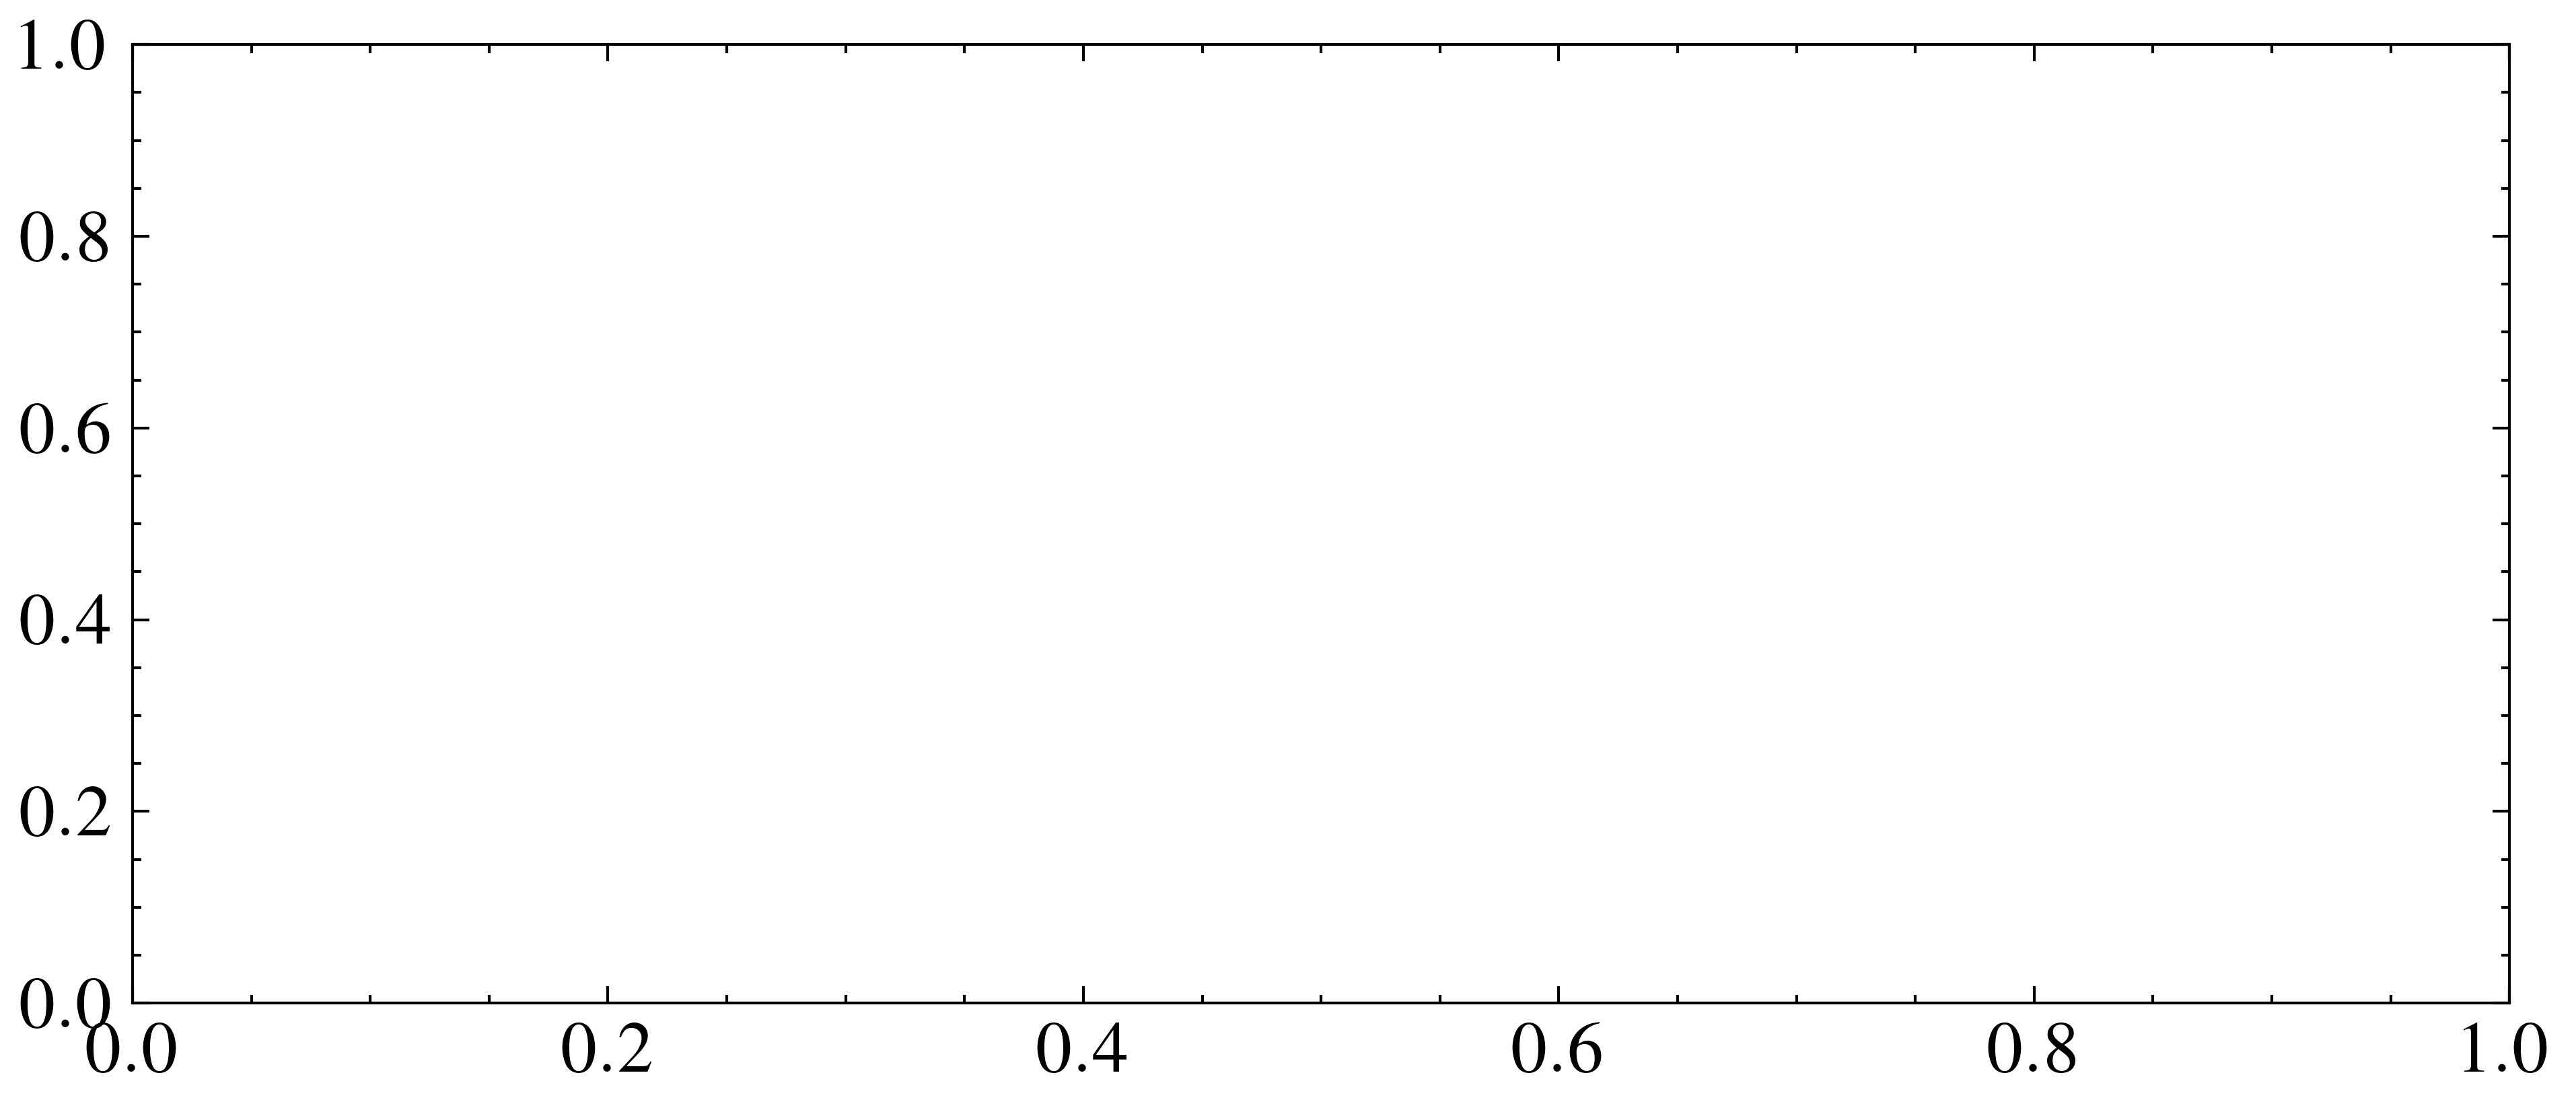

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample data and existing plot setup
# fig,ax= plt.subplots(1,1,figsize=(w,h)

# Prepare the DataFrame
# Assuming df is your DataFrame with SCH, REG, arrHour, and high_power columns
df_prices_all = df_prices_all[(df_prices_all['record_ts']  <= pd.Timestamp(year=2023, month=11, day=17,hour=0))]
filtered_df = df_prices_all[df_prices_all['high_power'] == 1]

# Grouping the data for box/violin plots
sch_prices = filtered_df.groupby('arrHour')['SCH'].apply(list)
reg_prices = filtered_df.groupby('arrHour')['REG'].apply(list)
hours = filtered_df['arrHour'].unique()

# Plot initial guess vs optimization result
fig, ax = plt.subplots(1, 1, figsize=(w, h))

# Existing plot
ax.plot(np.arange(0, 24, 0.25), tou[0], label='TOU Cost', ms=0, marker='X',
        linestyle="--", color=high_vis_map[2])

# Add scatter plots for SCH and REG prices
ax.scatter(filtered_df['arrHour'], filtered_df['SCH'],  label='SCH Prices', alpha=0.8,color=high_vis_map[3])
ax.scatter(filtered_df['arrHour'], filtered_df['REG'], facecolor="white",label='REG Prices', alpha=0.5,edgecolor=high_vis_map[4])
ax.axhline(198 , color=high_vis_map[4], 
                   linestyle='--', label = 'REG, $z_0$',lw=1)
ax.axhline(165 , color=high_vis_map[3], 
                   linestyle='--', label = 'SCH, $z_0$',lw=1)
ax.axhline(135 , color=high_vis_map[3], 
                   linestyle='--', label = 'SCH, $z_0$',lw=1)
# Set specific x-ticks
ax.set_xticks([0, 6, 12, 18])

# Set plot properties
ax.set_ylim(40, 275)
ax.set_xlim(0, 23)
ax.grid()
# ax.set_title("High Power Charging")
ax.set_xlabel("Hour of the Day")
ax.set_ylabel("Tariff (cents / hr)")
ax.legend(bbox_to_anchor=(0.5, 1.05), loc='center', ncol=6, fontsize=8)

plt.show()


In [261]:
df
df = df_high.copy()
plt.figure(figsize=(5, 3))
plt.scatter(df.index, df['SCH'], label='SCH', marker='o', color='blue',s=2)
plt.scatter(df.index, df['REG'], label='REG', marker='o', color='red',s=2)
plt.plot(tou['index'],tou[0])
# Setting labels, title and legend
plt.xlabel('Index')
plt.ylabel('Tariff (cents/hr)')
plt.title('High Power, TOU Tariff Range :98 - 240 cents/hr')
plt.legend(frameon=True)
plt.grid(True)

# # Format the x-axis
# ax = plt.gca()  # Get current axis
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))  # Major ticks every 3 hours
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %H:%M'))  # Day and hour
# plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
# Display the plot
plt.tight_layout()
plt.show()

NameError: name 'df_high' is not defined

In [29]:

# off-peak 0.175  cents / kwh 
TOU_tariff = np.ones((96,)) * 17.5
## 4 pm - 9 pm peak 0.367 cents / kwh 
TOU_tariff[64:84] = 36.7
## 9 am - 2 pm super off-peak 0.49 $ / kWh  to cents / kwh

TOU_tariff[36:56] = 14.9

In [30]:
high_TOU = TOU_tariff * 6.6
low_TOU = TOU_tariff * 3.3
low_TOU.max(),low_TOU.min()

(121.11, 49.17)

In [102]:
high_TOU = TOU_tariff * 6.6
tou = pd.DataFrame(high_TOU).reset_index(drop=False)
tou['index'] = tou['index'] / 4

In [103]:
tou

,index,0
0,0.00,115.5
1,0.25,115.5
2,0.50,115.5
3,0.75,115.5
4,1.00,115.5
...,...,...
91,22.75,115.5
92,23.00,115.5
93,23.25,115.5
94,23.50,115.5
